## Regression Analysis

In [1]:
#load needed libraries
import pandas as pd
import statsmodels.api as sm

In [2]:
#load dataset
df = pd.read_csv('../data_clean/master_dataset.csv')

In [3]:
#define vaiables
##dependent variable
y = df ['gld']

In [4]:
#independent variables
X =  df[['fsm', 'sen', 'idaci', 'ofsted', 'childcare_per_100', 'ethnic_diversity']]

In [5]:
#add constant for interception
X = sm.add_constant (X)

In [6]:
#run regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    gld   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     8.897
Date:                Mon, 25 May 2026   Prob (F-statistic):           2.54e-05
Time:                        18:47:11   Log-Likelihood:                -71.781
No. Observations:                  33   AIC:                             157.6
Df Residuals:                      26   BIC:                             168.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                51.4215     20.87

In [13]:
#select variables
variables = ['fsm', 'sen', 'idaci', 'ofsted', 'childcare_per_100', 'ethnic_diversity']

In [14]:
# variables where HIGH = BAD (colour logic flips)
negative_vars = ['fsm', 'idaci', 'sen']

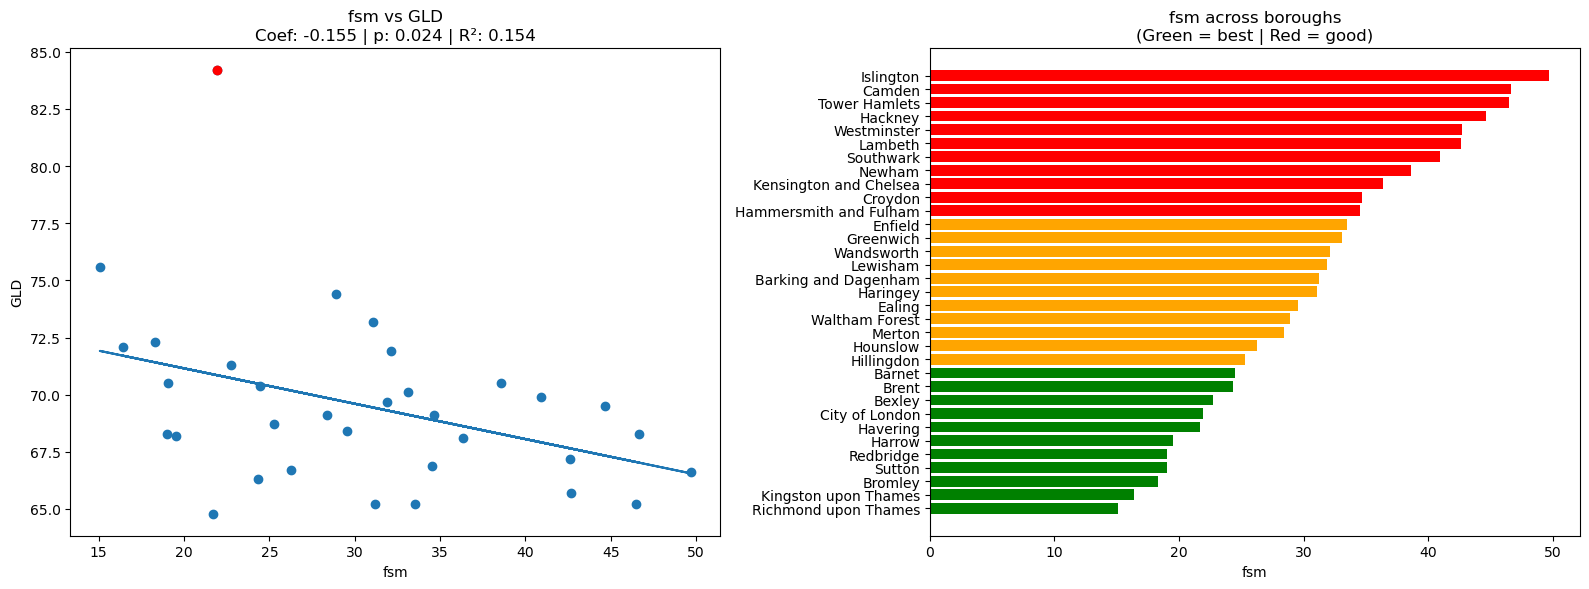

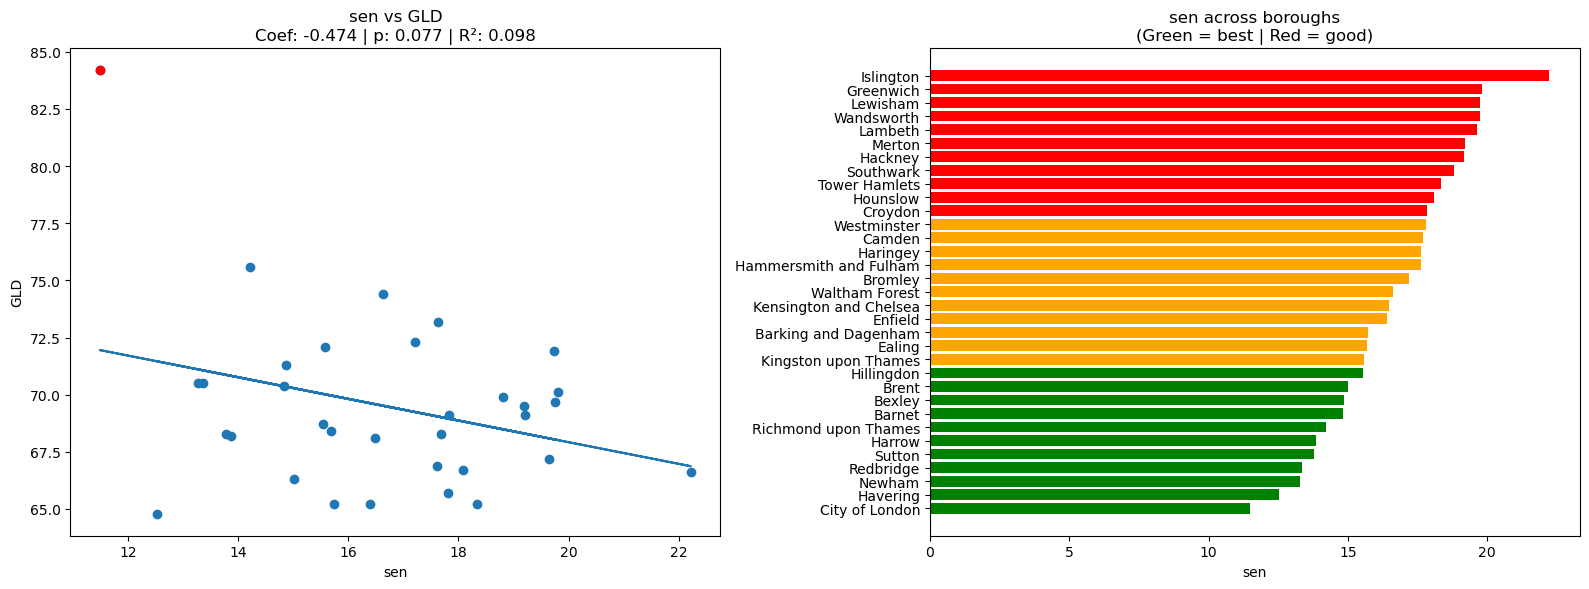

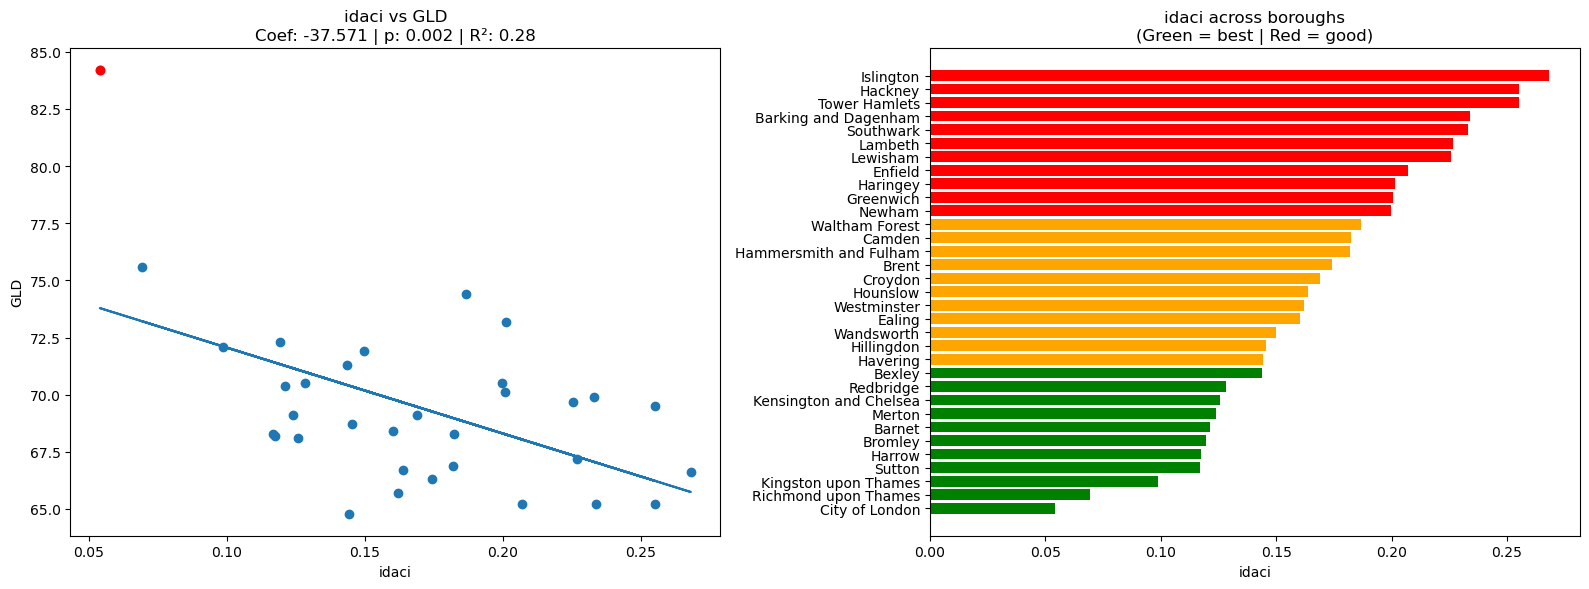

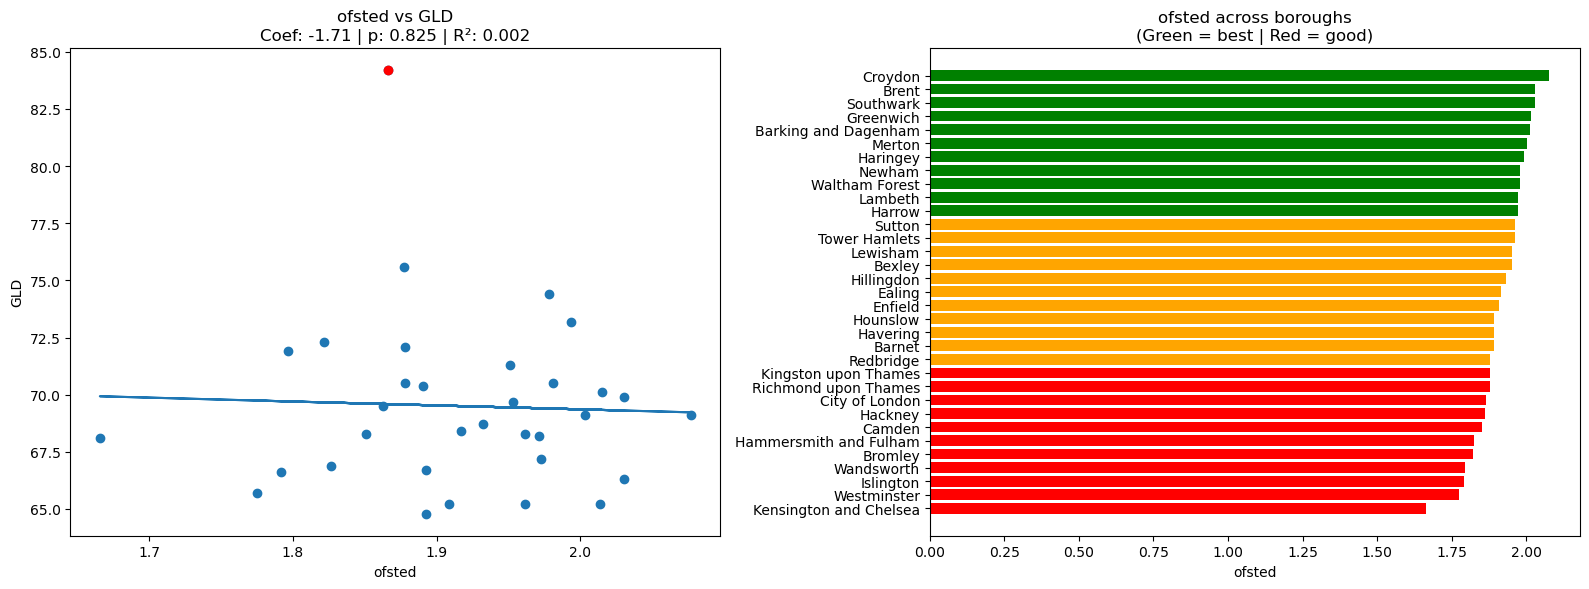

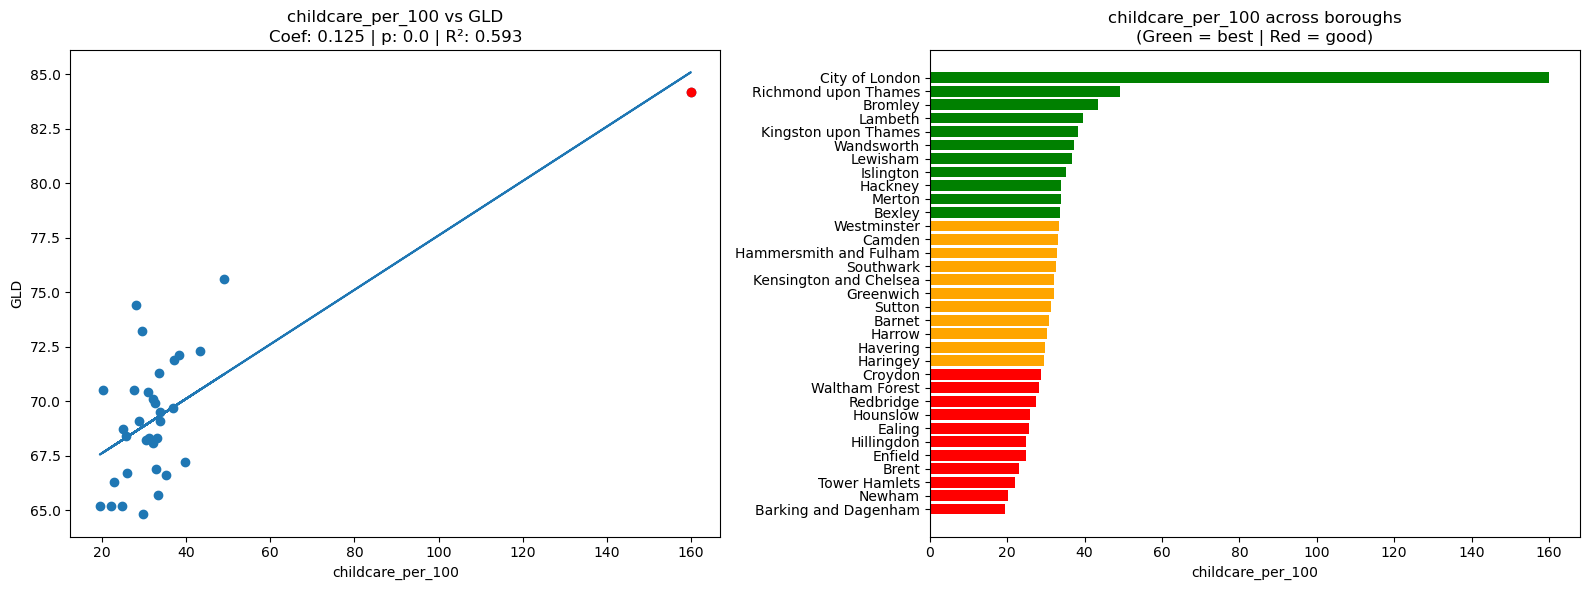

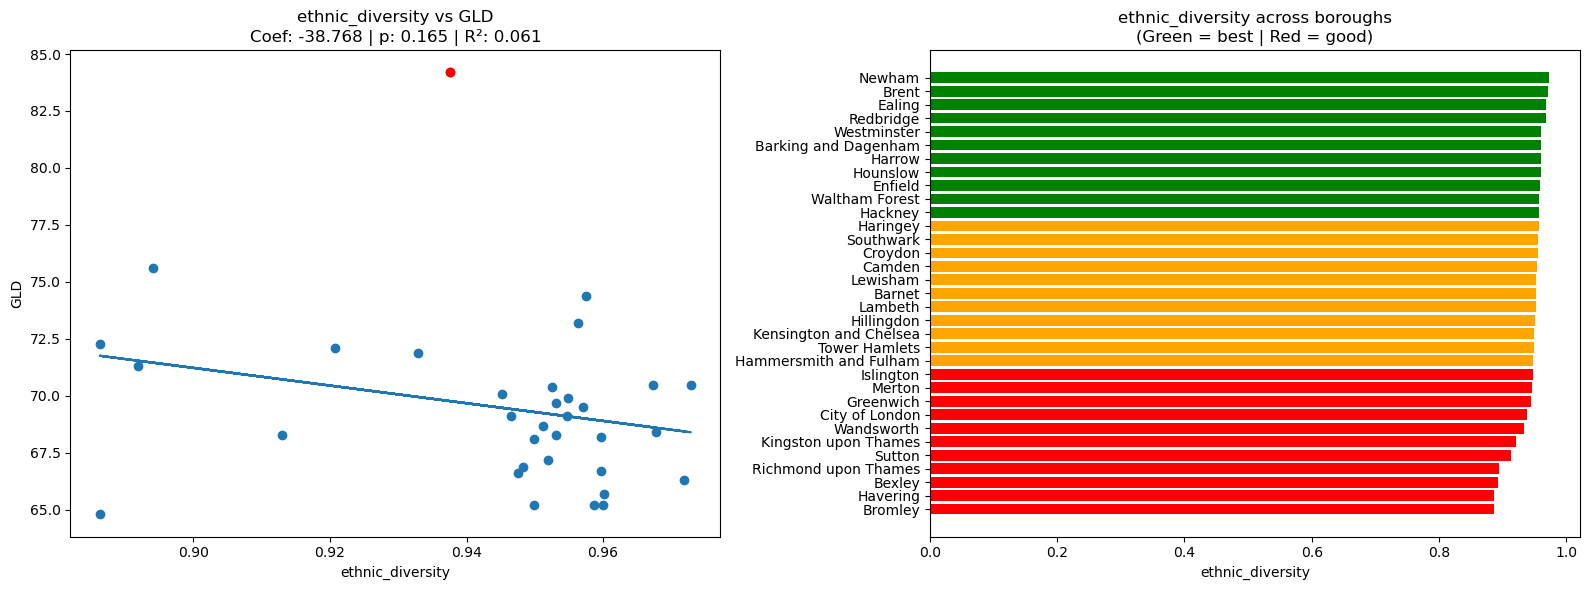

In [16]:
# LOOP THROUGH VARIABLES
for var in variables:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x = df[var]
    y = df['gld']

# -------------------------------
    # LEFT: SCATTER + TREND + REGRESSION
    # -------------------------------
    axes[0].scatter(x, y)
    
    # highlight City of London
    col = df[df['borough'] == 'City of London']
    axes[0].scatter(col[var], col['gld'], color='red')
    
    # regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    axes[0].plot(x, p(x))
    
    # regression model
    X = sm.add_constant(df[[var]])
    model = sm.OLS(y, X).fit()
    
    coef = round(model.params[var], 3)
    pval = round(model.pvalues[var], 3)
    r2 = round(model.rsquared, 3)
    
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('GLD')
    axes[0].set_title(
        f'{var} vs GLD\nCoef: {coef} | p: {pval} | R²: {r2}'
    )    
  # -------------------------------
    # RIGHT: BAR CHART (COLOUR-CODED)
    # -------------------------------
    df_sorted = df.sort_values(by=var)
    
    # thresholds
    low_threshold = df_sorted[var].quantile(0.33)
    high_threshold = df_sorted[var].quantile(0.66)
    
    colors = []
    
    for value in df_sorted[var]:
        if var in negative_vars:
            # reverse logic (low = good)
            if value <= low_threshold:
                colors.append('green')
            elif value >= high_threshold:
                colors.append('red')
            else:
                colors.append('orange')
        else:
            # normal logic (high = good)
            if value <= low_threshold:
                colors.append('red')
            elif value >= high_threshold:
                colors.append('green')
            else:
                colors.append('orange')
    
    axes[1].barh(df_sorted['borough'], df_sorted[var], color=colors)
    
    axes[1].set_title(
        f'{var} across boroughs\n(Green = best | Red = good)'
    )
    axes[1].set_xlabel(var)
    
    plt.tight_layout()
    plt.show()